# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Wildfire Risk Dataset](https://www.kaggle.com/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

/kaggle/input/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions/wildfire_multi_region_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('wildfire_multi_region_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


## last Five row

In [4]:
df.tail()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
15495,-29.5180,4.4481,2025-10-31,912,2025,10,Spring,D,Sub_Saharan_Africa,DRC,...,Suomi-NPP,VIIRS,348.45,77.70,High,low,29.8,0.6,2.55,12.7
15496,1.8911,38.6745,2025-10-31,101,2025,10,Autumn,N,Sub_Saharan_Africa,South Africa,...,Suomi-NPP,VIIRS,339.74,78.96,High,high,35.7,0.5,1.13,7.9
15497,-3.7720,-16.7081,2025-10-31,136,2025,10,Spring,N,Sub_Saharan_Africa,Mozambique,...,TERRA,MODIS,350.10,221.90,Extreme,high,34.2,4.9,1.15,20.1
15498,6.5688,-12.5954,2025-10-31,313,2025,10,Autumn,N,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,356.97,68.71,High,low,46.9,17.4,1.72,28.2
15499,-27.7634,44.2033,2025-10-31,1224,2025,10,Spring,D,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,306.19,123.82,High,high,36.3,8.7,3.28,11.4


## Shape of our dataset

In [5]:
df.shape

(15500, 21)

## List out all columns

In [6]:
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'frp_mw', 'fire_intensity', 'confidence',
       'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

latitude          float64
longitude         float64
acq_date           object
acq_time            int64
year                int64
month               int64
season             object
daynight           object
region             object
country            object
fire_type          object
satellite          object
instrument         object
brightness_k      float64
frp_mw            float64
fire_intensity     object
confidence         object
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  object 
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  object 
 7   daynight        15500 non-null  object 
 8   region          15500 non-null  object 
 9   country         15500 non-null  object 
 10  fire_type       15500 non-null  object 
 11  satellite       15500 non-null  object 
 12  instrument      15500 non-null  object 
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  object 
 16  confidence      15500 non-null  object 
 17  temp_max_c      15500 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

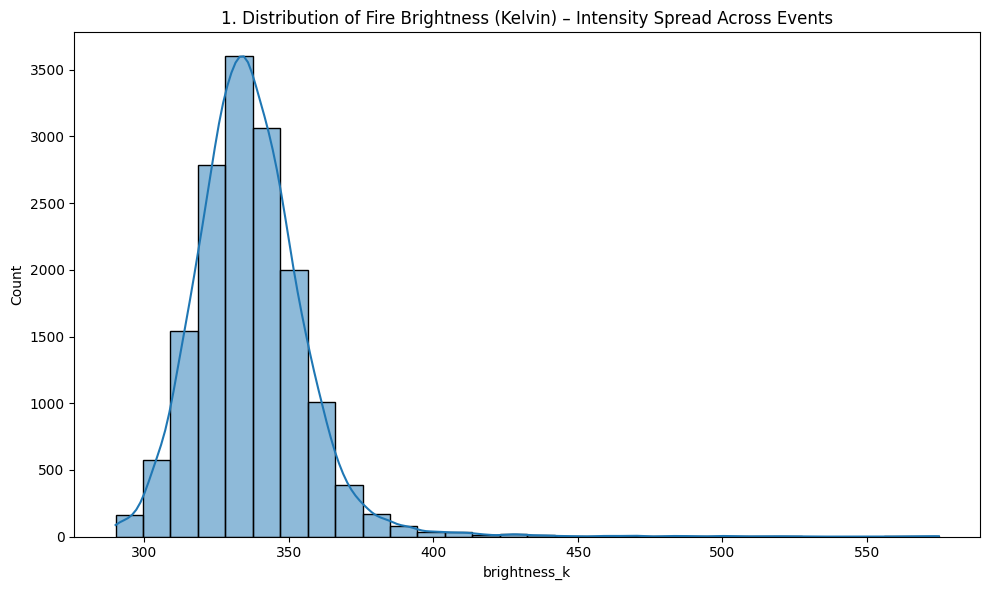

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['brightness_k'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Fire Brightness (Kelvin) – Intensity Spread Across Events')
show_fig()
plot_no += 1

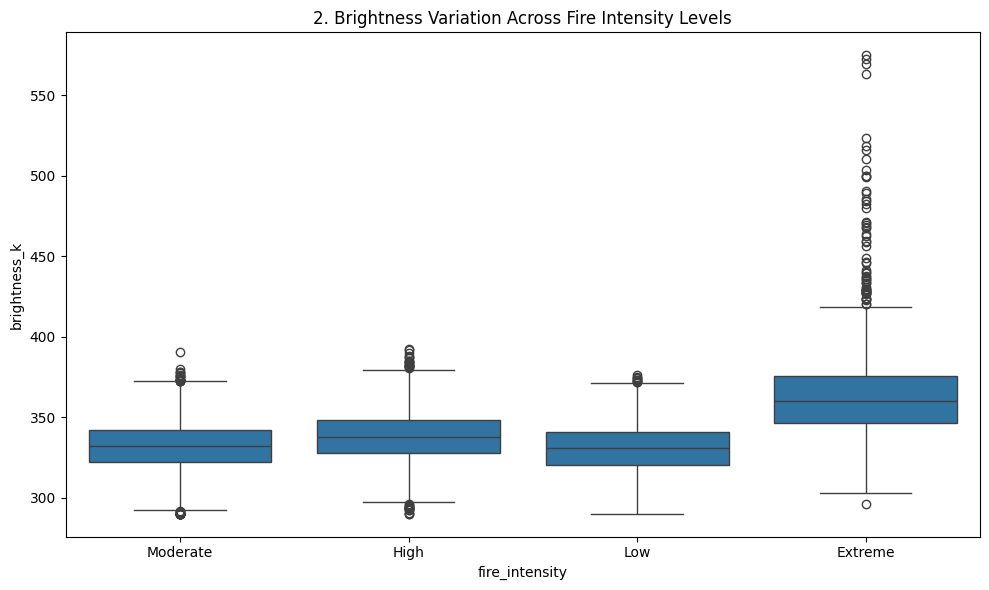

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='fire_intensity', y='brightness_k', data=df)
plt.title(f'{plot_no}. Brightness Variation Across Fire Intensity Levels')
show_fig()
plot_no += 1

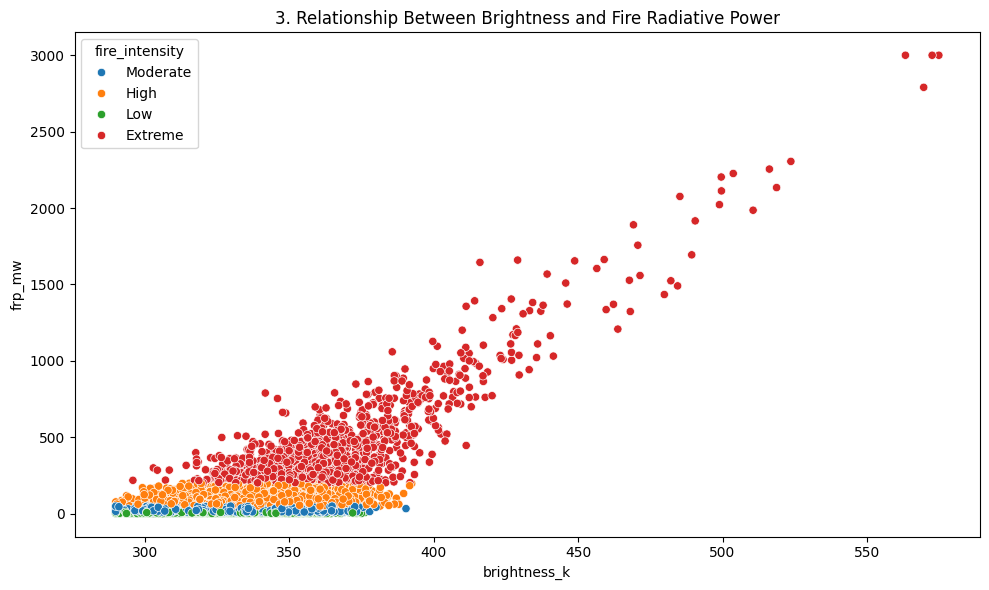

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='brightness_k', y='frp_mw', hue='fire_intensity', data=df)
plt.title(f'{plot_no}. Relationship Between Brightness and Fire Radiative Power')
show_fig()
plot_no += 1

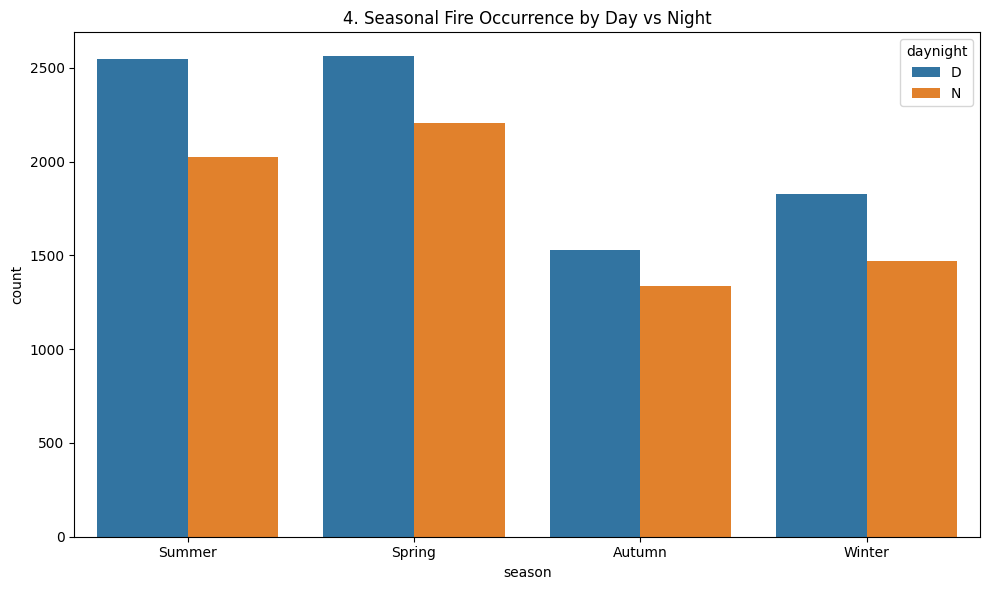

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='season', hue='daynight', data=df)
plt.title(f'{plot_no}. Seasonal Fire Occurrence by Day vs Night')
show_fig()
plot_no += 1

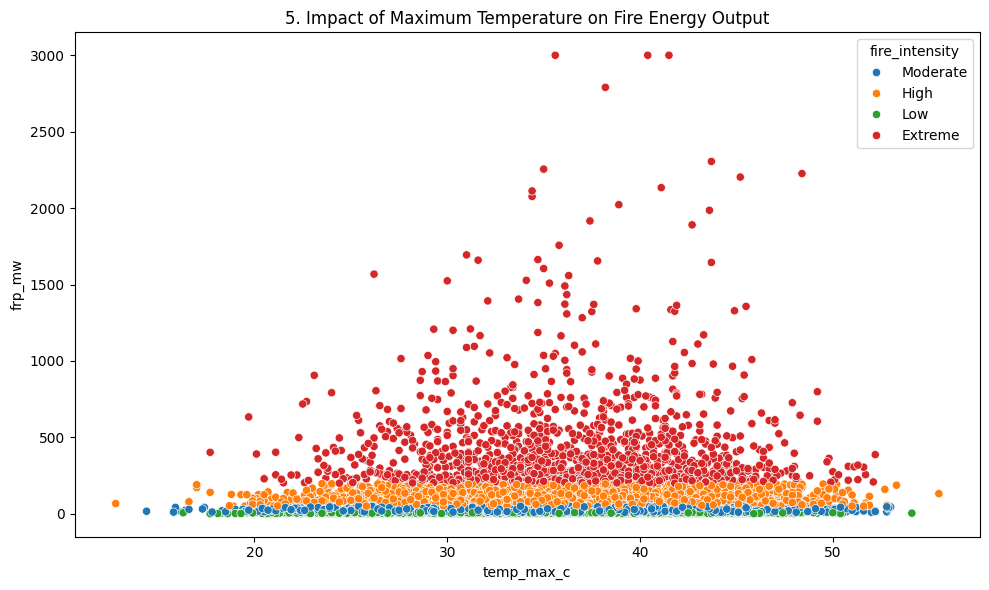

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='temp_max_c', y='frp_mw', hue='fire_intensity', data=df)
plt.title(f'{plot_no}. Impact of Maximum Temperature on Fire Energy Output')
show_fig()
plot_no += 1

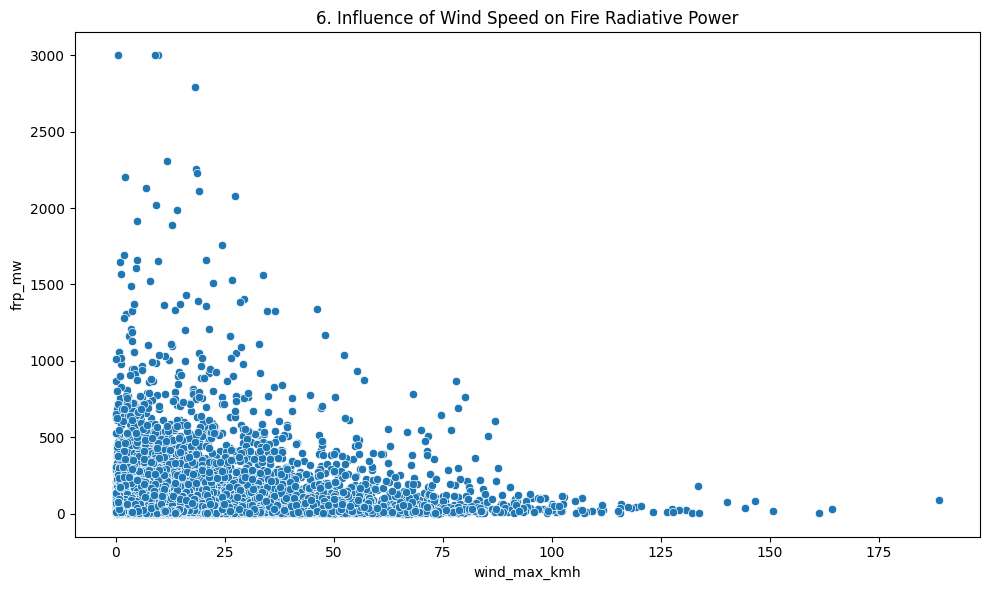

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='wind_max_kmh', y='frp_mw', data=df)
plt.title(f'{plot_no}. Influence of Wind Speed on Fire Radiative Power')
show_fig()
plot_no += 1

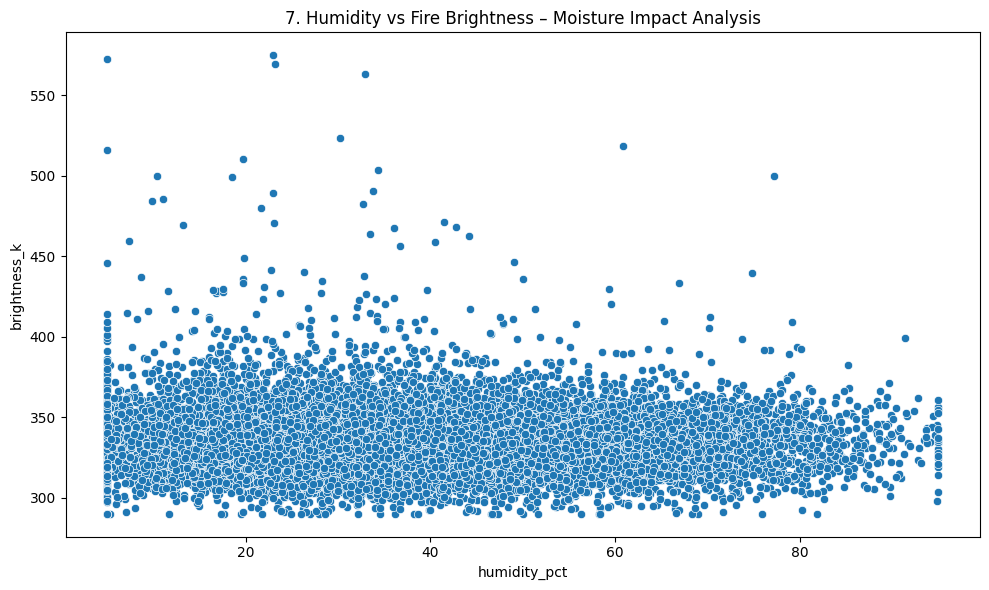

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='humidity_pct', y='brightness_k', data=df)
plt.title(f'{plot_no}. Humidity vs Fire Brightness – Moisture Impact Analysis')
show_fig()
plot_no += 1

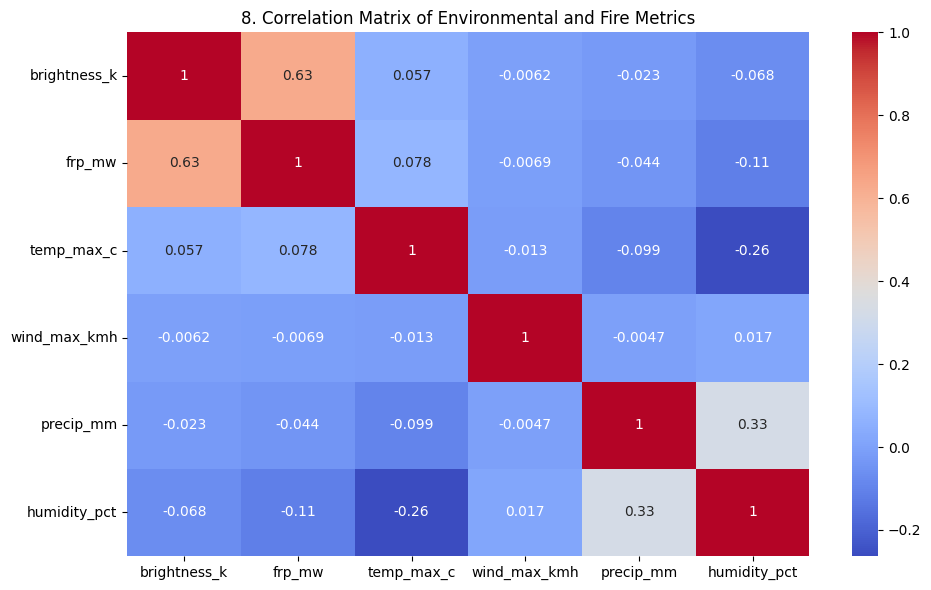

In [20]:
fig = plt.figure(figsize=(10,6))
corr = df[['brightness_k','frp_mw','temp_max_c','wind_max_kmh','precip_mm','humidity_pct']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Matrix of Environmental and Fire Metrics')
show_fig()
plot_no += 1

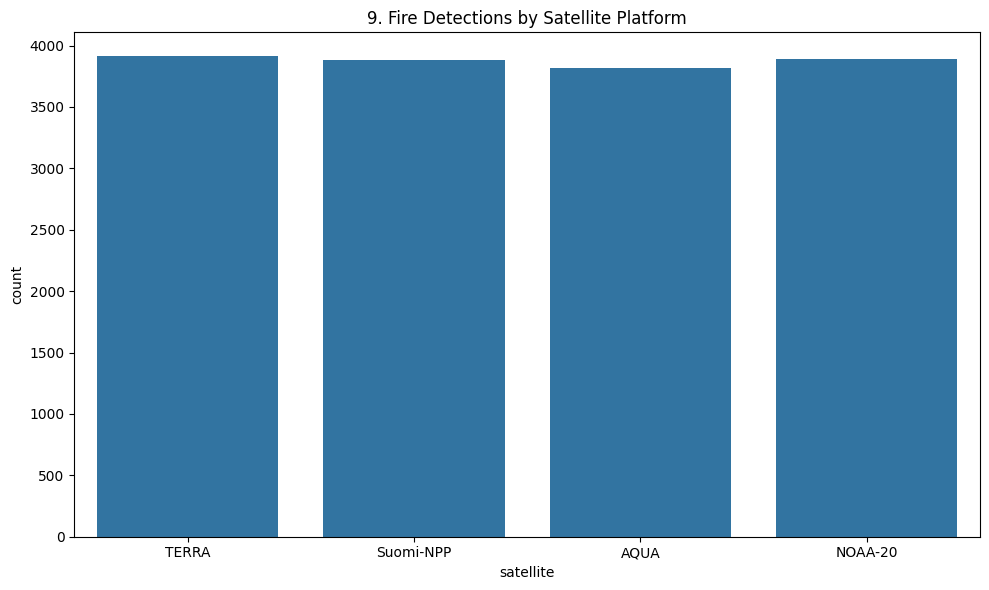

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='satellite', data=df)
plt.title(f'{plot_no}. Fire Detections by Satellite Platform')
show_fig()
plot_no += 1

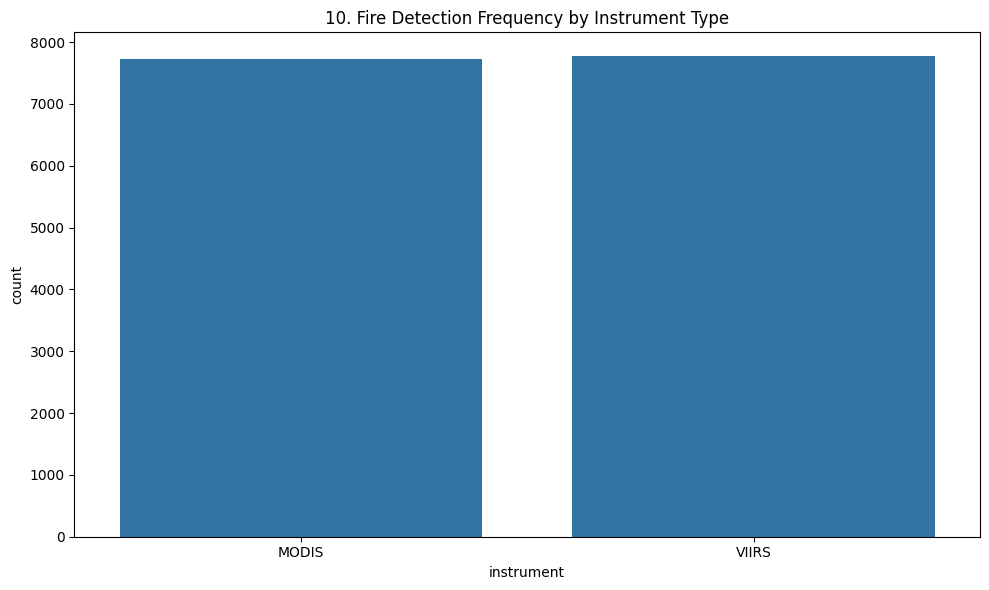

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='instrument', data=df)
plt.title(f'{plot_no}. Fire Detection Frequency by Instrument Type')
show_fig()
plot_no += 1

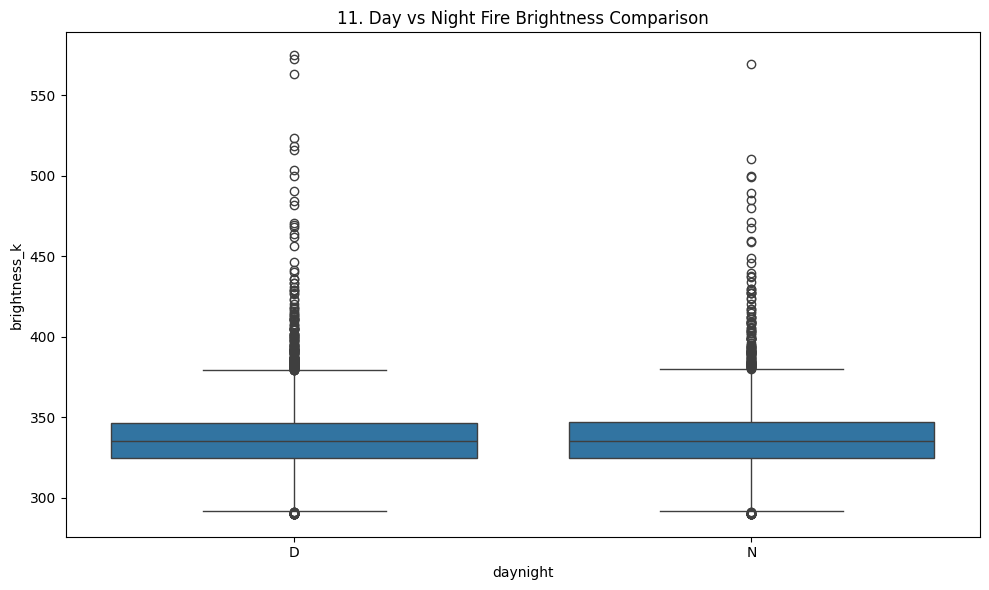

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='daynight', y='brightness_k', data=df)
plt.title(f'{plot_no}. Day vs Night Fire Brightness Comparison')
show_fig()
plot_no += 1

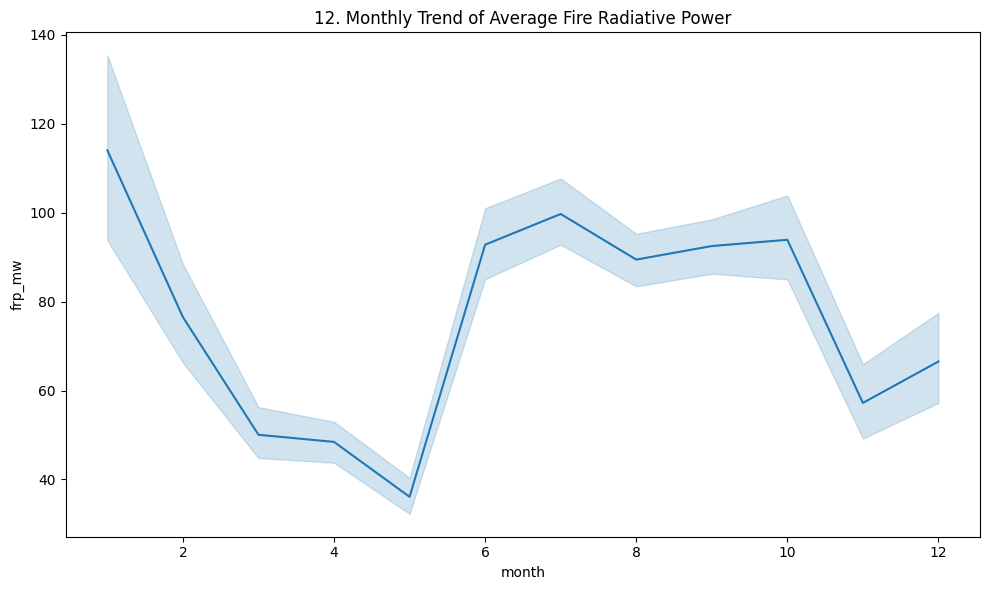

In [24]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='frp_mw', data=df, estimator='mean')
plt.title(f'{plot_no}. Monthly Trend of Average Fire Radiative Power')
show_fig()
plot_no += 1

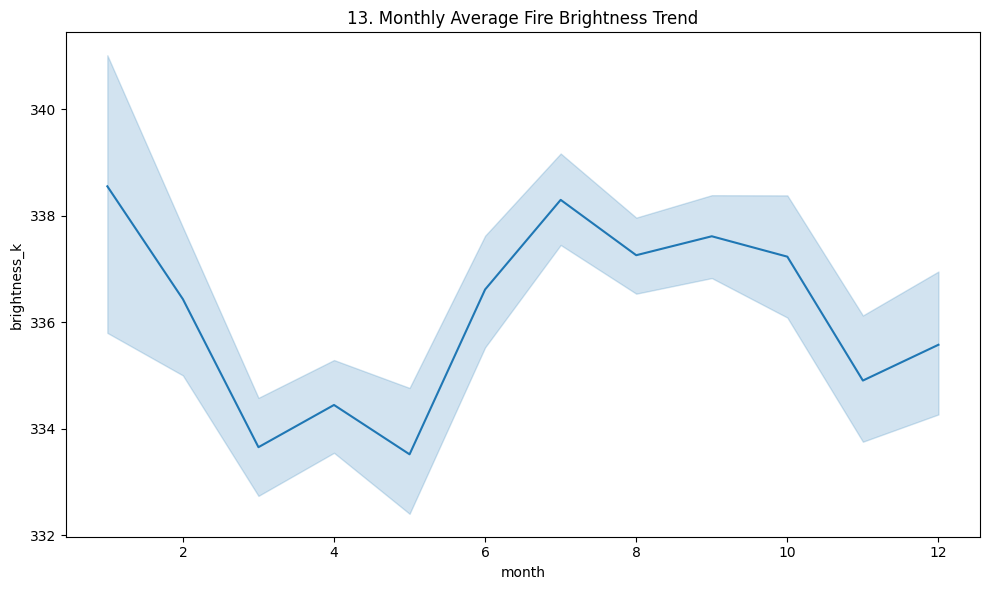

In [25]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='brightness_k', data=df, estimator='mean')
plt.title(f'{plot_no}. Monthly Average Fire Brightness Trend')
show_fig()
plot_no += 1

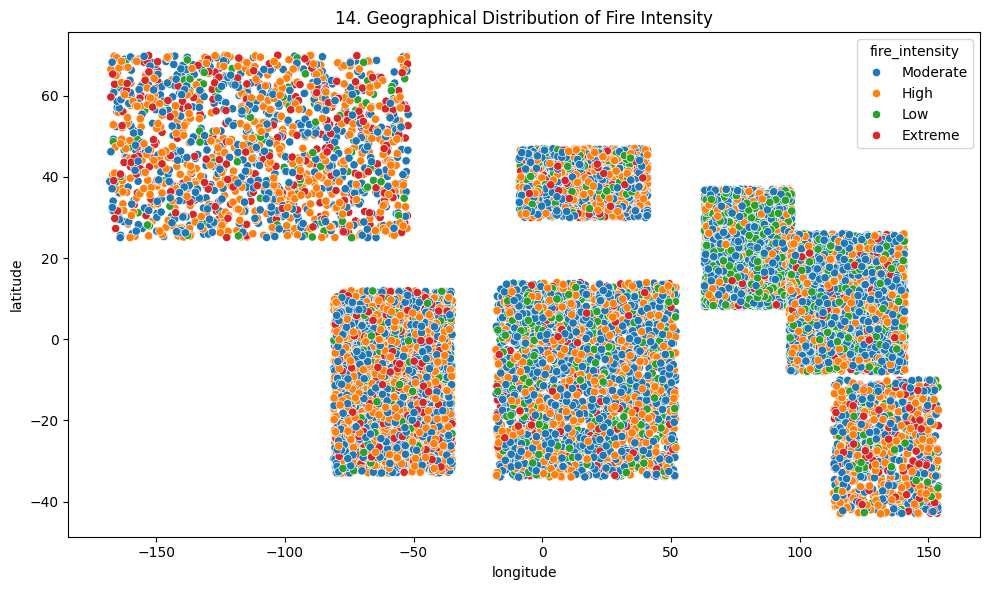

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='longitude', y='latitude', hue='fire_intensity', data=df)
plt.title(f'{plot_no}. Geographical Distribution of Fire Intensity')
show_fig()
plot_no += 1

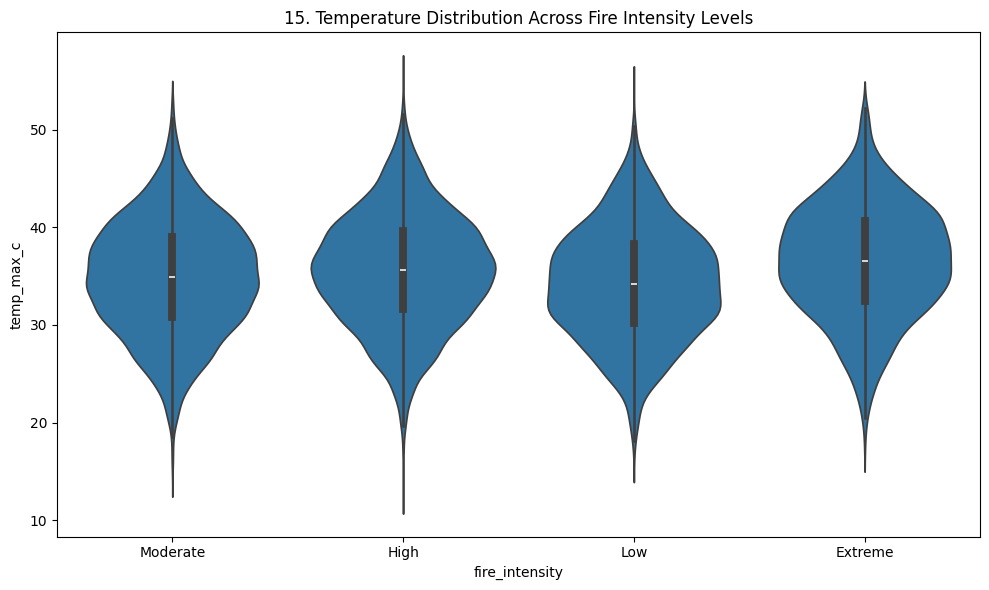

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='fire_intensity', y='temp_max_c', data=df)
plt.title(f'{plot_no}. Temperature Distribution Across Fire Intensity Levels')
show_fig()
plot_no += 1

# Model Training

## Select target variable

In [28]:
target = 'fire_intensity'

## Drop unnecessary columns

In [29]:
drop_cols = ['latitude','longitude','acq_date','acq_time','year','country']
X = df.drop(columns=drop_cols + [target])
y = df[target]

## Identify numerical and categorical columns

In [30]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing pipeline (scaling + encoding)

In [31]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## Create final pipeline with Gradient Boosting model

In [32]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

## Split dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train model

In [34]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['month', 'brightness_k', 'frp_mw', 'temp_max_c', 'wind_max_kmh',
       'precip_mm', 'humidity_pct'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['season', 'daynight', 'region', 'fire_type', 'satellite', 'instrument',
       'confidence'],
      dtype='object'))])),
                ('classifier', GradientBoostingClassifier())])

## Predict on test data

In [35]:
y_pred = model.predict(X_test)

## Calculate accuracy

In [36]:
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(acc*100, 2), "%")

Model Accuracy: 100.0 %


## Generate confusion matrix

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=model.named_steps['classifier'].classes_)

## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

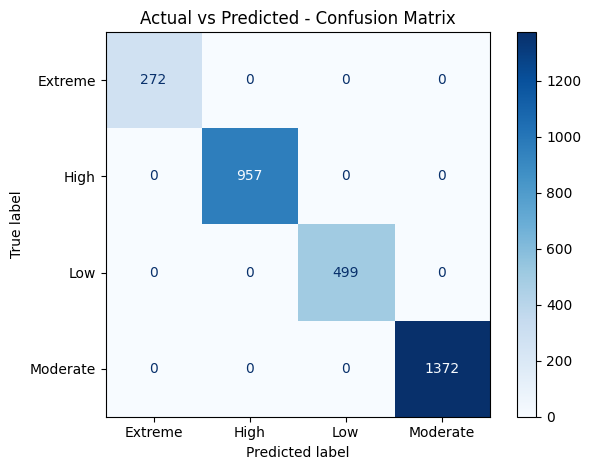

In [38]:
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.named_steps['classifier'].classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Actual vs Predicted - Confusion Matrix")
plt.tight_layout()
plt.show()